In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
from Temis.dataloader import German

# Common Auxiliary Libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Uncommon Auxiliary Libraries
import jax 
import jax.numpy as jnp

# Machine Learning Models Libraries
from Temis.models import LogisticRegression as FairLR
from Temis.models import MinimaxFairness
from sklearn.linear_model import LogisticRegression as SKLearnLR

# Machine Learning Metrics Libraries
from sklearn.metrics import roc_auc_score, log_loss
from Temis.comparison_utils.cmp_fairness import extract_fairness

# Testing the dataloader definition

In [8]:
from Temis.preprocess_data import preprocess_german
german_path = os.path.join("..", "datasets", "german", "german.data")
preprocess_german(german_path)

Starting preprocess_german
Importing Data from German Dataset...


In [9]:
german_preprocessed_path = os.path.join('..', 'data', 'preprocessed', 'german.csv')
german = German(german_preprocessed_path)
X_train, y_train = german.get_train_data()
X_test, y_test = german.get_test_data()

print(f"len(X_train): {len(X_train)}")
print(f"len(y_train): {len(y_train)}")
print(f"len(X_test): {len(X_test)}")
print(f"len(y_test): {len(y_test)}")
print(X_train['ForeignWorker_A202'])

len(X_train): 750
len(y_train): 750
len(X_test): 250
len(y_test): 250
121    0.0
267    0.0
503    0.0
664    0.0
124    0.0
      ... 
597    0.0
404    0.0
567    0.0
880    0.0
809    0.0
Name: ForeignWorker_A202, Length: 750, dtype: float64


# Testing the Rpr logistic regression

In [13]:
s_attribute = 'ForeignWorker_A202'

In [33]:
model_fair = FairLR(epochs=100, penalty='l2', penalty_weight=1.0, fair_penalty='Rpr', fair_penalty_weight=10.0)
model_fair.fit(X_train, y_train, S=X_train['ForeignWorker_A202'], debug=False)
fair_pred_test = model_fair.predict(X_test)
fair_prob_test = model_fair.predict_proba(X_test)

In [34]:
# By default uses 'l2' penalty
model_sk = SKLearnLR(solver='lbfgs', max_iter=1000)
model_sk.fit(X_train, y_train)
sk_pred_test = model_sk.predict(X_test)
sk_prob_test = model_sk.predict(X_test)

In [35]:
print(f'AUC: {roc_auc_score(y_test, fair_prob_test)}')
print(f'AUC: {roc_auc_score(y_test, sk_prob_test)}')

AUC: 0.7381781595851714
AUC: 0.6445321569537962


# Testing the MinimaxFairness Approach

In [52]:
mask0_train = X_train[s_attribute] == 0
mask1_train = X_train[s_attribute] == 1

mask0_test = X_test[s_attribute] == 0
mask1_test = X_test[s_attribute] == 1

print(len(y_train[mask0_train]))
print(len(y_train[mask1_train]))
print(len(y_test[mask0_test]))
print(len(y_test[mask1_test]))

baseline_model = SKLearnLR(solver='lbfgs', max_iter=1000)
baseline_model.fit(X_train, y_train)

baseline_pred_train_class0 = log_loss(y_train[mask0_train], baseline_model.predict_proba(X_train)[mask0_train])
baseline_pred_train_class1 = log_loss(y_train[mask1_train], baseline_model.predict_proba(X_train)[mask1_train])

baseline_pred_test_class0 = log_loss(y_test[mask0_test], baseline_model.predict_proba(X_test)[mask0_test])
baseline_pred_test_class1 = log_loss(y_test[mask1_test], baseline_model.predict_proba(X_test)[mask1_test])

722
28
241
9


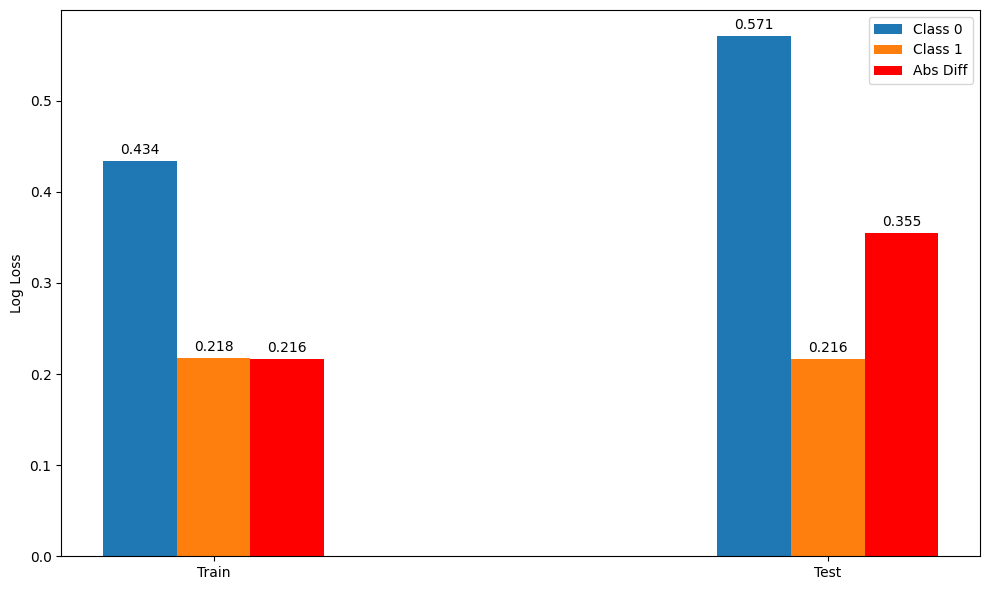

In [54]:
# Fairness log-loss comparison for the standard sklearnLr.

labels = ['Train', 'Test']
loss_class0 = [baseline_pred_train_class0, baseline_pred_test_class0]
loss_class1 = [baseline_pred_train_class1, baseline_pred_test_class1]

diff_train = abs(baseline_pred_train_class0 - baseline_pred_train_class1)
diff_test = abs(baseline_pred_test_class0 - baseline_pred_test_class1)
loss_diff = [diff_train, diff_test]

x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 6))
bars_class0 = ax.bar(
    x - width/3,
    loss_class0,
    width/3,
    label='Class 0',
    color='#1f77b4'
)

bars_class1 = ax.bar(
    x,
    loss_class1,
    width/3,
    label='Class 1',
    color='#ff7f0e'
)

bars_diff = ax.bar(
    x + width/3,
    loss_diff,
    width/3,
    label='Abs Diff',
    color='#ff0000'
)

ax.set_ylabel('Log Loss')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(bars_class0, padding=3, fmt='%.3f')
ax.bar_label(bars_class1, padding=3, fmt='%.3f')
ax.bar_label(bars_diff, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()

In [46]:
model_base = SKLearnLR(solver='lbfgs', max_iter=250)
mm_model = MinimaxFairness(model_base, iter=1000)
mm_model.fit(X_train, y_train, X_train[s_attribute])

In [47]:
mm_pred_train_class0 = log_loss(y_train[mask0_train], mm_model.predict_proba(X_train)[mask0_train])
mm_pred_train_class1 = log_loss(y_train[mask1_train], mm_model.predict_proba(X_train)[mask1_train])

mm_pred_test_class0 = log_loss(y_test[mask0_test], mm_model.predict_proba(X_test)[mask0_test])
mm_pred_test_class1 = log_loss(y_test[mask1_test], mm_model.predict_proba(X_test)[mask1_test])

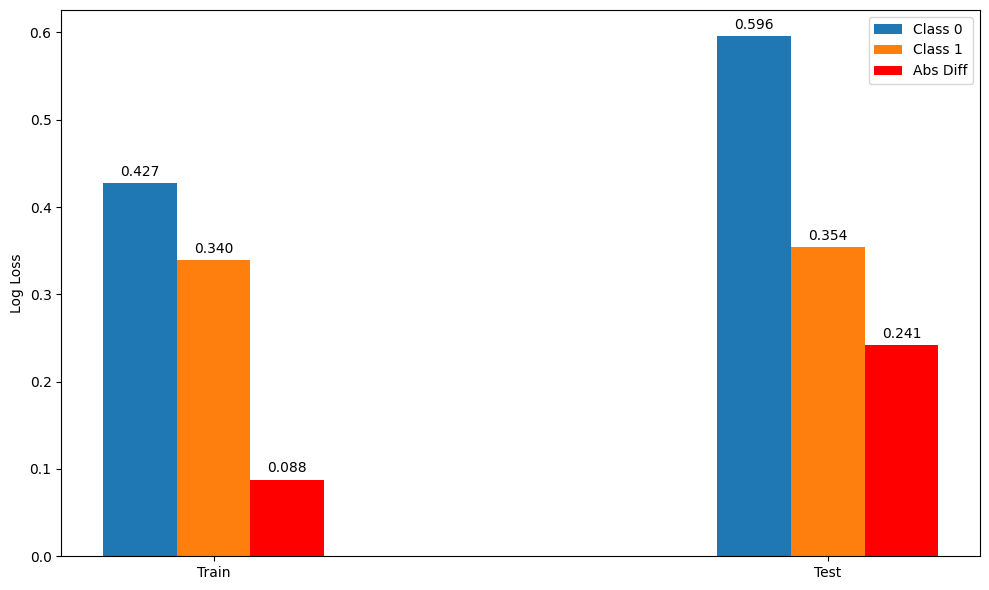

In [55]:
# Fairness log-loss comparison for the standard sklearnLr.

labels = ['Train', 'Test']
loss_class0 = [mm_pred_train_class0, mm_pred_test_class0]
loss_class1 = [mm_pred_train_class1, mm_pred_test_class1]

diff_train = abs(mm_pred_train_class0 - mm_pred_train_class1)
diff_test = abs(mm_pred_test_class0 - mm_pred_test_class1)
loss_diff = [diff_train, diff_test]

x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 6))
bars_class0 = ax.bar(
    x - width/3,
    loss_class0,
    width/3,
    label='Class 0',
    color='#1f77b4'
)

bars_class1 = ax.bar(
    x,
    loss_class1,
    width/3,
    label='Class 1',
    color='#ff7f0e'
)

bars_diff = ax.bar(
    x + width/3,
    loss_diff,
    width/3,
    label='Abs Diff',
    color='#ff0000'
)

ax.set_ylabel('Log Loss')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(bars_class0, padding=3, fmt='%.3f')
ax.bar_label(bars_class1, padding=3, fmt='%.3f')
ax.bar_label(bars_diff, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()

In [49]:
weight_history = mm_model.lambdas_history
loss_history = mm_model.group_losses_history

weight_group0 = np.array([item[False] for item in weight_history])
weight_group1 = np.array([item[True] for item in weight_history])

loss_group0 = np.array([item[False] for item in loss_history])
loss_group1 = np.array([item[True] for item in loss_history])

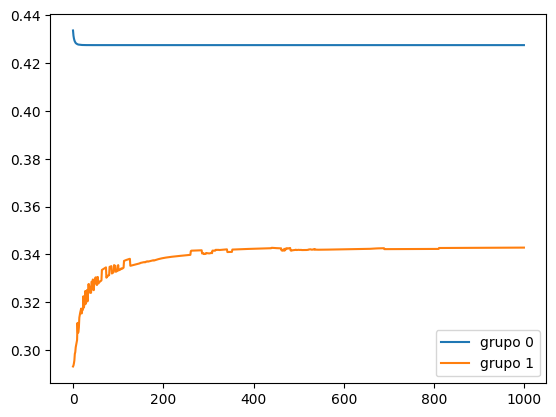

In [50]:
# Plot loss overtime:
size = len(weight_group0)
x = np.arange(0, size)

plt.plot(x, loss_group0, label='grupo 0')
plt.plot(x, loss_group1, label='grupo 1')

plt.legend()

plt.show()

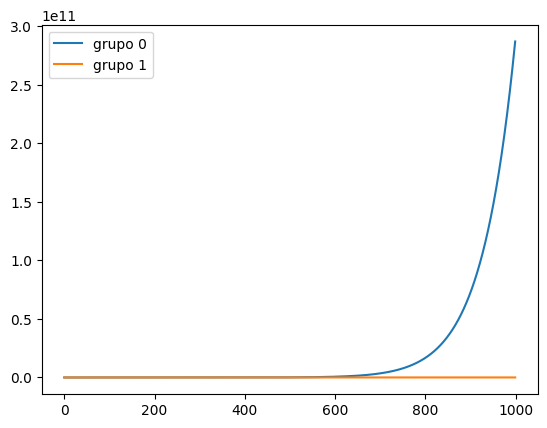

In [51]:
size = len(weight_group0)
x = np.arange(0, size)

plt.plot(x, weight_group0, label='grupo 0')
plt.plot(x, weight_group1, label='grupo 1')

plt.legend()

plt.show()

# Experimento: Evolução do MinimaxFairness com variação de iter

In [ ]:
# Variar o parâmetro iter e coletar diff_train e diff_test
iter_values = [10, 50, 100, 250, 500, 750, 1000, 1500, 2000]
diff_train_values = []
diff_test_values = []

for iter_param in iter_values:
    print(f"Treinando modelo com iter={iter_param}...")
    
    model_base = SKLearnLR(solver='lbfgs', max_iter=250)
    mm_model = MinimaxFairness(model_base, iter=iter_param)
    mm_model.fit(X_train, y_train, groups=X_train[s_attribute])
    
    # Calcular predições
    mm_pred_train_class0 = log_loss(y_train[mask0_train], mm_model.predict_proba(X_train)[mask0_train])
    mm_pred_train_class1 = log_loss(y_train[mask1_train], mm_model.predict_proba(X_train)[mask1_train])
    
    mm_pred_test_class0 = log_loss(y_test[mask0_test], mm_model.predict_proba(X_test)[mask0_test])
    mm_pred_test_class1 = log_loss(y_test[mask1_test], mm_model.predict_proba(X_test)[mask1_test])
    
    # Calcular diferenças
    diff_train = abs(mm_pred_train_class0 - mm_pred_train_class1)
    diff_test = abs(mm_pred_test_class0 - mm_pred_test_class1)
    
    diff_train_values.append(diff_train)
    diff_test_values.append(diff_test)
    
    print(f"  Diff Train: {diff_train:.4f}, Diff Test: {diff_test:.4f}")

print("Experimento concluído!")

Treinando modelo com iter=10...
  Diff Train: 0.1337, Diff Test: 0.2620
Treinando modelo com iter=50...
  Diff Train: 0.1374, Diff Test: 0.2773
Treinando modelo com iter=100...
  Diff Train: 0.1338, Diff Test: 0.2801
Treinando modelo com iter=250...
  Diff Train: 0.1167, Diff Test: 0.2788
Treinando modelo com iter=500...
  Diff Train: 0.1029, Diff Test: 0.2760
Treinando modelo com iter=750...
  Diff Train: 0.0964, Diff Test: 0.2746
Treinando modelo com iter=1000...
  Diff Train: 0.0927, Diff Test: 0.2740
Treinando modelo com iter=1500...
  Diff Train: 0.0886, Diff Test: 0.2733
Treinando modelo com iter=2000...
  Diff Train: 0.0865, Diff Test: 0.2729
Experimento concluído!


In [ ]:
# Plotar a evolução das curvas Abs Diff (Train vs Test)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(iter_values, diff_train_values, marker='o', linewidth=2, markersize=8, label='Train', color='#1f77b4')
ax.plot(iter_values, diff_test_values, marker='s', linewidth=2, markersize=8, label='Test', color='#ff7f0e')

ax.set_xlabel('Número de Iterações (iter)', fontsize=12)
ax.set_ylabel('Abs Diff (Log Loss)', fontsize=12)
ax.set_title('Evolução da Fairness com variação do parâmetro iter - MinimaxFairness', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Adicionar valores nos pontos
for i, (iter_val, train_val, test_val) in enumerate(zip(iter_values, diff_train_values, diff_test_values)):
    ax.text(iter_val, train_val + 0.01, f'{train_val:.4f}', ha='center', va='top', fontsize=9)
    ax.text(iter_val, test_val + 0.01, f'{test_val:.4f}', ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()

In [34]:
# Variar o parâmetro iter e coletar diff_train e diff_test
iter_values = [10, 50, 100, 250, 500, 750, 1000, 1500, 2000]
diff_train_values = []
diff_test_values = []

for iter_param in iter_values:
    print(f"Treinando modelo com iter={iter_param}...")
    
    fairLR_model = FairLR(epochs=iter_param, penalty='l2', penalty_weight=1.0, fair_penalty='Rpr', fair_penalty_weight=100.0)
    fairLR_model.fit(X_train, y_train, S=X_train[s_attribute])
    
    # Calcular predições
    fairLR_pred_train_class0 = log_loss(y_train[mask0_train], fairLR_model.predict_proba(X_train)[mask0_train.values])
    fairLR_pred_train_class1 = log_loss(y_train[mask1_train], fairLR_model.predict_proba(X_train)[mask1_train.values])
    
    fairLR_pred_test_class0 = log_loss(y_test[mask0_test], fairLR_model.predict_proba(X_test)[mask0_test.values])
    fairLR_pred_test_class1 = log_loss(y_test[mask1_test], fairLR_model.predict_proba(X_test)[mask1_test.values])
    
    # Calcular diferenças
    diff_train = abs(fairLR_pred_train_class0 - fairLR_pred_train_class1)
    diff_test = abs(fairLR_pred_test_class0 - fairLR_pred_test_class1)
    
    diff_train_values.append(diff_train)
    diff_test_values.append(diff_test)
    
    print(f"  Diff Train: {diff_train:.4f}, Diff Test: {diff_test:.4f}")

print("Experimento concluído!")

Treinando modelo com iter=10...
  Diff Train: 0.2131, Diff Test: 0.0742
Treinando modelo com iter=50...
  Diff Train: 0.1684, Diff Test: 0.0626
Treinando modelo com iter=100...
  Diff Train: 0.1930, Diff Test: 0.0895
Treinando modelo com iter=250...
  Diff Train: 0.1984, Diff Test: 0.0599
Treinando modelo com iter=500...
  Diff Train: 0.2241, Diff Test: 0.0765
Treinando modelo com iter=750...
  Diff Train: 0.2125, Diff Test: 0.0852
Treinando modelo com iter=1000...
  Diff Train: 0.2014, Diff Test: 0.0725
Treinando modelo com iter=1500...
  Diff Train: 0.1899, Diff Test: 0.0780
Treinando modelo com iter=2000...
  Diff Train: 0.1878, Diff Test: 0.0839
Experimento concluído!


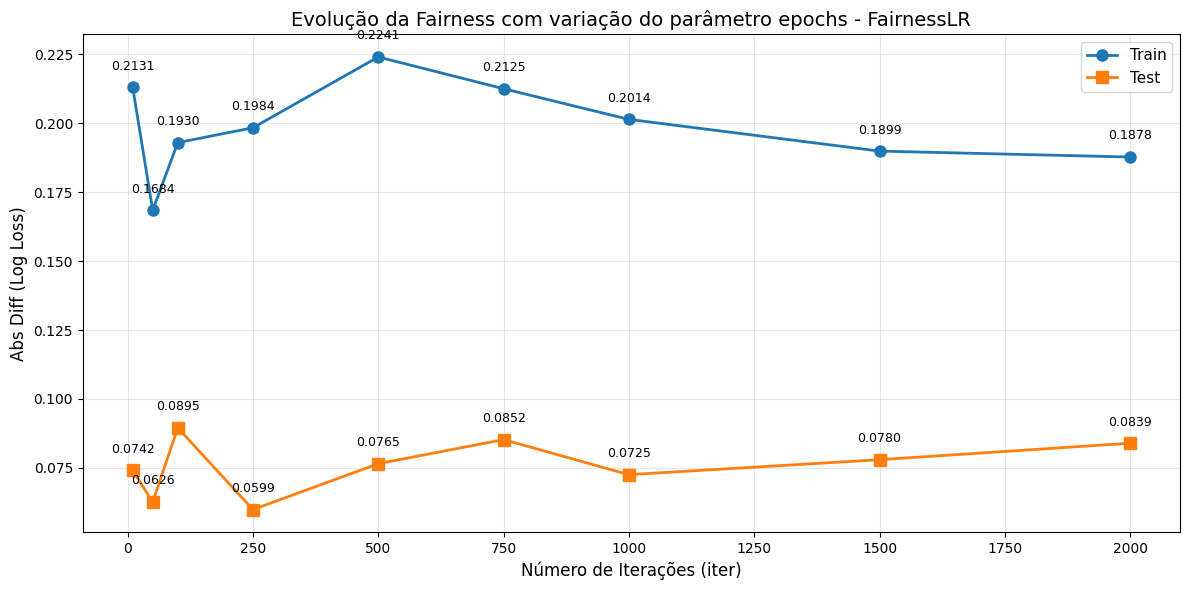

In [35]:
# Plotar a evolução das curvas Abs Diff (Train vs Test)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(iter_values, diff_train_values, marker='o', linewidth=2, markersize=8, label='Train', color='#1f77b4')
ax.plot(iter_values, diff_test_values, marker='s', linewidth=2, markersize=8, label='Test', color='#ff7f0e')

ax.set_xlabel('Número de Iterações (iter)', fontsize=12)
ax.set_ylabel('Abs Diff (Log Loss)', fontsize=12)
ax.set_title('Evolução da Fairness com variação do parâmetro epochs - FairnessLR', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Adicionar valores nos pontos
for i, (iter_val, train_val, test_val) in enumerate(zip(iter_values, diff_train_values, diff_test_values)):
    ax.text(iter_val, train_val + 0.01, f'{train_val:.4f}', ha='center', va='top', fontsize=9)
    ax.text(iter_val, test_val + 0.01, f'{test_val:.4f}', ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()

# Testing Metrics Propose in the Paper:

In [9]:
from Temis.metrics.prejudice_index import normalized_prejudice_index
from Temis.metrics.cvs import calders_verwer_score
from sklearn.metrics import accuracy_score

random_state = 46

german_preprocessed_path = os.path.join('..', 'data', 'preprocessed', 'german.csv')
german = German(german_preprocessed_path, test_size=0.2, random_state=random_state)
X_train, y_train = german.get_train_data()
X_test, y_test = german.get_test_data()

# We can only use A92 since there are no A95 samples
S_train = X_train['PersonalStatusAndSex_A92']
S_test = X_test['PersonalStatusAndSex_A92']

models = [
    (
        'sklearn_lr',
        SKLearnLR(max_iter=1000),
    ),
    (
        'fair_lr_3',
        FairLR(
            epochs=1000,
            penalty='l2',
            penalty_weight=1.0,
            fair_penalty='Rpr',
            fair_penalty_weight=3.0,
        ),
    ),
    (
        'fair_lr_4',
        FairLR(
            epochs=1000,
            penalty='l2',
            penalty_weight=1.0,
            fair_penalty='Rpr',
            fair_penalty_weight=4.0,
        ),
    ),
    (
        'fair_lr_5',
        FairLR(
            epochs=1000,
            penalty='l2',
            penalty_weight=1.0,
            fair_penalty='Rpr',
            fair_penalty_weight=5.0,
        ),
    ),
    (
        'fair_lr_6',
        FairLR(
            epochs=1000,
            penalty='l2',
            penalty_weight=1.0,
            fair_penalty='Rpr',
            fair_penalty_weight=6.0,
        ),
    ),
    (
        'fair_lr_7',
        FairLR(
            epochs=1000,
            penalty='l2',
            penalty_weight=1.0,
            fair_penalty='Rpr',
            fair_penalty_weight=7.0,
        ),
    ),
    (
        'fair_lr_8',
        FairLR(
            epochs=1000,
            penalty='l2',
            penalty_weight=1.0,
            fair_penalty='Rpr',
            fair_penalty_weight=8.0,
        ),
    ),
    (
        'fair_lr_9',
        FairLR(
            epochs=1000,
            penalty='l2',
            penalty_weight=1.0,
            fair_penalty='Rpr',
            fair_penalty_weight=9.0,
        ),
    ),
    (
        'fair_lr_10',
        FairLR(
            epochs=1000,
            penalty='l2',
            penalty_weight=1.0,
            fair_penalty='Rpr',
            fair_penalty_weight=10.0,
        ),
    ),
    (
        'fair_lr_15',
        FairLR(
            epochs=1000,
            penalty='l2',
            penalty_weight=1.0,
            fair_penalty='Rpr',
            fair_penalty_weight=15.0,
        ),
    ),
    (
        'fair_lr_30',
        FairLR(
            epochs=1000,
            penalty='l2',
            penalty_weight=1.0,
            fair_penalty='Rpr',
            fair_penalty_weight=30.0,
        ),
    ),
    (
        'fair_lr_40',
        FairLR(
            epochs=1000,
            penalty='l2',
            penalty_weight=1.0,
            fair_penalty='Rpr',
            fair_penalty_weight=40.0,
        ),
    ),
    (
        'fair_lr_100',
        FairLR(
            epochs=1000,
            penalty='l2',
            penalty_weight=1.0,
            fair_penalty='Rpr',
            fair_penalty_weight=100.0,
        ),
    ),
]

rows = []

for model_name, model in models:
    if model_name == 'sklearn_lr':
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train, y_train, S=S_train)
        y_pred = np.asarray(model.predict(X_test))

    y_pred = np.asarray(y_pred).astype(int)

    rows.append(
        {
            'model': model_name,
            'accuracy': float(accuracy_score(y_test, y_pred)),
            'normalized_prejudice_index': float(normalized_prejudice_index(y_pred, S_test.astype(int))),
            'cvs': float(calders_verwer_score(y_pred, S_test.astype(int))),
        }
    )

report_df = pd.DataFrame(rows)
report_df = report_df.round(
    {
        'accuracy': 3,
        'normalized_prejudice_index': 6,
        'cvs': 6,
    }
)
report_df

,model,accuracy,normalized_prejudice_index,cvs
0,sklearn_lr,0.750,0.024296,0.191223
1,fair_lr_3,0.720,0.002265,0.033229
2,fair_lr_4,0.720,0.002265,0.033229
3,fair_lr_5,0.720,0.002265,0.033229
4,fair_lr_6,0.720,0.002265,0.033229
5,fair_lr_7,0.725,0.001338,0.026332
6,fair_lr_8,0.730,0.000689,0.019436
7,fair_lr_9,0.730,0.000689,0.019436
8,fair_lr_10,0.730,0.000689,0.019436
9,fair_lr_15,0.730,0.000689,0.019436


In [6]:
group_name = 'PersonalStatusAndSex_A92'

train_counts = X_train[group_name].astype(int).value_counts().sort_index()
test_counts = X_test[group_name].astype(int).value_counts().sort_index()

train_props = X_train[group_name].astype(int).value_counts(normalize=True).sort_index()
test_props = X_test[group_name].astype(int).value_counts(normalize=True).sort_index()

train_minority = float(train_counts.min() / train_counts.max())
test_minority = float(test_counts.min() / test_counts.max())

print('Train counts:')
print(train_counts)
print()
print('Train proportions:')
print(train_props)
print()
print(f'Train minority/majority ratio: {train_minority:.4f}')
print()
print('Test counts:')
print(test_counts)
print()
print('Test proportions:')
print(test_props)
print()
print(f'Test minority/majority ratio: {test_minority:.4f}')

Train counts:
PersonalStatusAndSex_A92
0    545
1    255
Name: count, dtype: int64

Train proportions:
PersonalStatusAndSex_A92
0    0.68125
1    0.31875
Name: proportion, dtype: float64

Train minority/majority ratio: 0.4679

Test counts:
PersonalStatusAndSex_A92
0    145
1     55
Name: count, dtype: int64

Test proportions:
PersonalStatusAndSex_A92
0    0.725
1    0.275
Name: proportion, dtype: float64

Test minority/majority ratio: 0.3793


In [4]:
group_name = 'PersonalStatusAndSex_A92'

train_counts = X_train[group_name].astype(int).value_counts().sort_index()
test_counts = X_test[group_name].astype(int).value_counts().sort_index()

train_props = X_train[group_name].astype(int).value_counts(normalize=True).sort_index()
test_props = X_test[group_name].astype(int).value_counts(normalize=True).sort_index()

print('Train counts:')
print(train_counts)
print()
print('Train proportions:')
print(train_props)
print()
print()
print('Test counts:')
print(test_counts)
print()
print('Test proportions:')
print(test_props)
print()

Train counts:
PersonalStatusAndSex_A92
0    545
1    255
Name: count, dtype: int64

Train proportions:
PersonalStatusAndSex_A92
0    0.68125
1    0.31875
Name: proportion, dtype: float64


Test counts:
PersonalStatusAndSex_A92
0    145
1     55
Name: count, dtype: int64

Test proportions:
PersonalStatusAndSex_A92
0    0.725
1    0.275
Name: proportion, dtype: float64

